This e-commerce analysis examined customer behavior, sales performance, product profitability, marketing effectiveness, customer satisfaction, retention patterns, and customer segmentation using transaction, product, customer, session, and review data from 2020–2024.
Overall, the business demonstrates stable performance with consistent revenue, customer activity, and spending behavior. While acquisition channels successfully generate customers and revenue, retention and customer loyalty remain the largest opportunities for future growth.


  Dataset includes tables such as:

- customers.csv — customer profiles, signup dates, country, opt-in
- products.csv — catalog with categories, prices, costs, margins
- sessions.csv — session metadata (device, source, start time, country)
- events.csv — page_view / add_to_cart / checkout / purchase with timestamps
- orders.csv — order headers (payment, discount, totals)
- order_items.csv — line items (quantity, unit price, line total)
- reviews.csv — product ratings & short text reviews

In [131]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\customers.csv")
products = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\products.csv")
sessions = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\sessions.csv")
events = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\events.csv")
orders = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\orders.csv")
order_items = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\order_items.csv")
reviews = pd.read_csv(r"C:\Users\marin\OneDrive\Documents\e-commerce syntethic\data\reviews.csv")

In [132]:
###Data Quality Assesement 
for name, df in {
    'customers': customers,
    'products': products,
    'sessions': sessions,
    'events': events,
    'orders': orders,
    'order_items': order_items,
    'reviews': reviews
}.items():
    print('\n', name)
    print(df.shape)
    print(df.columns.tolist())


 customers
(20000, 7)
['customer_id', 'name', 'email', 'country', 'age', 'signup_date', 'marketing_opt_in']

 products
(1197, 6)
['product_id', 'category', 'name', 'price_usd', 'cost_usd', 'margin_usd']

 sessions
(120000, 6)
['session_id', 'customer_id', 'start_time', 'device', 'source', 'country']

 events
(760958, 10)
['event_id', 'session_id', 'timestamp', 'event_type', 'product_id', 'qty', 'cart_size', 'payment', 'discount_pct', 'amount_usd']

 orders
(33580, 10)
['order_id', 'customer_id', 'order_time', 'payment_method', 'discount_pct', 'subtotal_usd', 'total_usd', 'country', 'device', 'source']

 order_items
(59163, 5)
['order_id', 'product_id', 'unit_price_usd', 'quantity', 'line_total_usd']

 reviews
(10780, 6)
['review_id', 'order_id', 'product_id', 'rating', 'review_text', 'review_time']


In [133]:
for name, df in {
    'customers': customers,
    'products': products,
    'sessions': sessions,
    'events': events,
    'orders': orders,
    'order_items': order_items,
    'reviews': reviews
}.items():

    print(f'\n{name.upper()}')
    print('Duplicates:', df.duplicated().sum())
    print('\nMissing values:')
    print(df.isna().sum())


CUSTOMERS
Duplicates: 0

Missing values:
customer_id         0
name                0
email               0
country             0
age                 0
signup_date         0
marketing_opt_in    0
dtype: int64

PRODUCTS
Duplicates: 0

Missing values:
product_id    0
category      0
name          0
price_usd     0
cost_usd      0
margin_usd    0
dtype: int64

SESSIONS
Duplicates: 0

Missing values:
session_id     0
customer_id    0
start_time     0
device         0
source         0
country        0
dtype: int64

EVENTS
Duplicates: 0

Missing values:
event_id             0
session_id           0
timestamp            0
event_type           0
product_id       78489
qty             617832
cart_size       716049
payment         727378
discount_pct    727378
amount_usd      727378
dtype: int64

ORDERS
Duplicates: 0

Missing values:
order_id          0
customer_id       0
order_time        0
payment_method    0
discount_pct      0
subtotal_usd      0
total_usd         0
country           0
devi

In [134]:
order_items[order_items.duplicated()].head()

,order_id,product_id,unit_price_usd,quantity,line_total_usd
1134,629,528,173.62,1,173.62
1361,754,24,42.86,1,42.86
2412,1359,1148,6.96,1,6.96
3335,1895,866,25.45,1,25.45
4609,2626,1064,36.15,1,36.15


In [135]:
order_items[order_items.duplicated()].shape

(73, 5)

In [136]:
duplicates = order_items[order_items.duplicated(keep=False)]

duplicates.sort_values(['order_id', 'product_id'])

,order_id,product_id,unit_price_usd,quantity,line_total_usd
1133,629,528,173.62,1,173.62
1134,629,528,173.62,1,173.62
1360,754,24,42.86,1,42.86
1361,754,24,42.86,1,42.86
2411,1359,1148,6.96,1,6.96
...,...,...,...,...,...
53419,30285,444,26.35,1,26.35
55319,31418,377,5.50,1,5.50
55320,31418,377,5.50,1,5.50
58228,33065,387,31.86,1,31.86


In [137]:
duplicates = order_items[order_items.duplicated(keep=False)]

duplicates.groupby(
    ['order_id', 'product_id',
     'unit_price_usd',
     'quantity',
     'line_total_usd']
).size().value_counts()

2    73
Name: count, dtype: int64

In [138]:
order_items = order_items.drop_duplicates()

In [139]:
for name, df in {
    'products': products,
    'orders': orders,
    'order_items': order_items,
}.items():

    print(f'\n{name.upper()}')
    print( df.describe())
 
    


PRODUCTS
        product_id    price_usd     cost_usd   margin_usd
count  1197.000000  1197.000000  1197.000000  1197.000000
mean    599.000000   119.935171    77.626483    42.308688
std     345.688444   119.681742    79.228858    44.464057
min       1.000000     3.500000     2.210000     1.030000
25%     300.000000    38.540000    23.530000    12.240000
50%     599.000000    77.200000    49.140000    27.020000
75%     898.000000   165.420000   103.670000    55.440000
max    1197.000000   596.620000   446.100000   263.730000

ORDERS
           order_id   customer_id  discount_pct  subtotal_usd     total_usd
count  33580.000000  33580.000000  33580.000000  33580.000000  33580.000000
mean   16790.500000  10010.629899      7.160214    144.002627    133.806357
std     9693.855356   5798.458913      7.474901    162.603585    152.130611
min        1.000000      1.000000      0.000000      3.500000      2.800000
25%     8395.750000   4964.000000      0.000000     44.060000     40.300000
50% 

In [140]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

sessions['start_time'] = pd.to_datetime(sessions['start_time'])

events['timestamp'] = pd.to_datetime(events['timestamp'])

orders['order_time'] = pd.to_datetime(orders['order_time'])

reviews['review_time'] = pd.to_datetime(reviews['review_time'])


In [141]:
print(
    orders['order_time'].min(),
    orders['order_time'].max()
)

2020-01-01 01:10:58 2025-10-31 22:59:41


In [142]:
print(
    events['timestamp'].min(),
    events['timestamp'].max()
)

2020-01-01 00:32:18 2025-11-01 01:50:04


In [143]:
orders['year'] = orders['order_time'].dt.year
orders['month'] = orders['order_time'].dt.month
orders['month_name'] = orders['order_time'].dt.strftime('%b')

In [144]:
orders = orders[orders['year'] <= 2024]

     Data Quality Assessment

- No missing values were found in the customers, products, orders, sessions, and reviews tables.
- Missing values in the events table are expected because certain attributes are only applicable to specific event types.
- 73 duplicate records were identified in the order_items table and removed.
- Date columns were converted to datetime format for time-based analysis.
- Overall data quality was sufficient for further exploratory and business analysis.
- Keeping only complete years (2020–2024) for year-over-year comparison.
  

In [145]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text
load_dotenv("credentials.env", override=True)

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")


#connection
engine = create_engine(

    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")
# download
with engine.begin() as conn:
    customers.to_sql('customers', con=conn, if_exists='replace', index=False)
    products.to_sql('products', con=conn, if_exists='replace', index=False)
    sessions.to_sql('sessions', con=conn, if_exists='replace', index=False)
    events.to_sql('events', con=conn, if_exists='replace', index=False)
    orders.to_sql('orders', con=conn, if_exists='replace', index=False)
    order_items.to_sql('order_items', con=conn, if_exists='replace', index=False)
    reviews.to_sql('reviews', con=conn, if_exists='replace', index=False)

print("All tables loaded successfully!")

All tables loaded successfully!


 ### 1. Business Overview

 Key Questions

 
- How many customers does the company have?
- How many orders were placed?
- What is the total revenue generated?
- What is the average order value (AOV)?

In [146]:
yearly_summary_query = """
SELECT
    year,
    SUM(total_usd) AS revenue,
    COUNT(order_id) AS orders_count,
    SUM(total_usd) / COUNT(order_id) AS aov,
    COUNT(DISTINCT customer_id) AS unique_customers
FROM orders
GROUP BY year
ORDER BY year
"""

yearly_summary = pd.read_sql(yearly_summary_query, engine)
yearly_summary

,year,revenue,orders_count,aov,unique_customers
0,2020,749090.77,5659,132.371580,4907
1,2021,786074.66,5831,134.809580,5053
2,2022,759726.17,5699,133.308680,4997
3,2023,779730.15,5739,135.865159,5046
4,2024,756280.45,5774,130.980334,5014


### Key Findings

- Revenue remained relatively stable between 2020 and 2024, fluctuating between 749K and 786K USD.
- The number of orders stayed consistent at approximately 5.7K orders per year.
- Average Order Value remained stable around 131–136 USD, indicating consistent customer spending behavior.
- The business served roughly 5,000 unique customers annually with no significant growth or decline.
- Overall, the company demonstrates stable performance with predictable sales volume and customer activity over the observed period.


### 2. Sales Performance Analysis

Key Questions

- How does revenue change over time?
- Are there any seasonal trends?
- Which months generate the highest sales?
- How does Average Order Value change over time?


<Axes: xlabel='year', ylabel='revenue'>

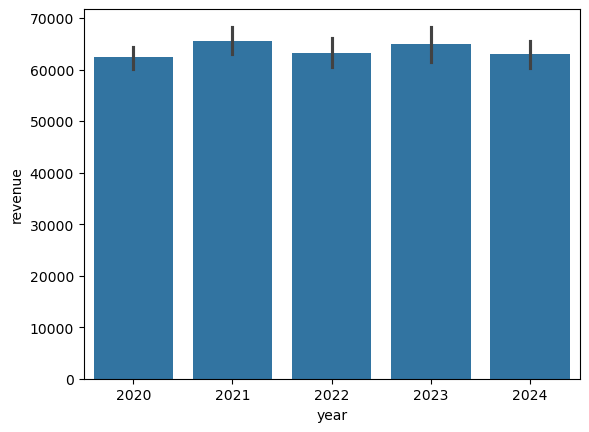

In [147]:
year_revenue = """
SELECT
    year,month,
    SUM(total_usd) AS revenue
FROM orders
GROUP BY year,month
ORDER BY year,month
"""

year_revenue = pd.read_sql(year_revenue, engine)

sns.barplot(
    data=year_revenue,
    x='year',
    y='revenue'
)

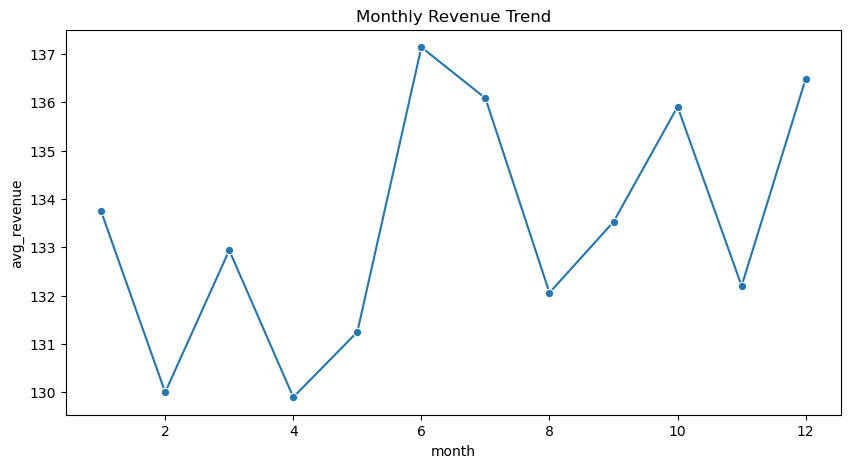

In [148]:
revenue_change = """
SELECT
    month,
    AVG(total_usd) AS avg_revenue
FROM orders
GROUP BY month
ORDER BY month; """
revenue_change = pd.read_sql(revenue_change, engine)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=revenue_change,
    x='month',
    y='avg_revenue',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.show()

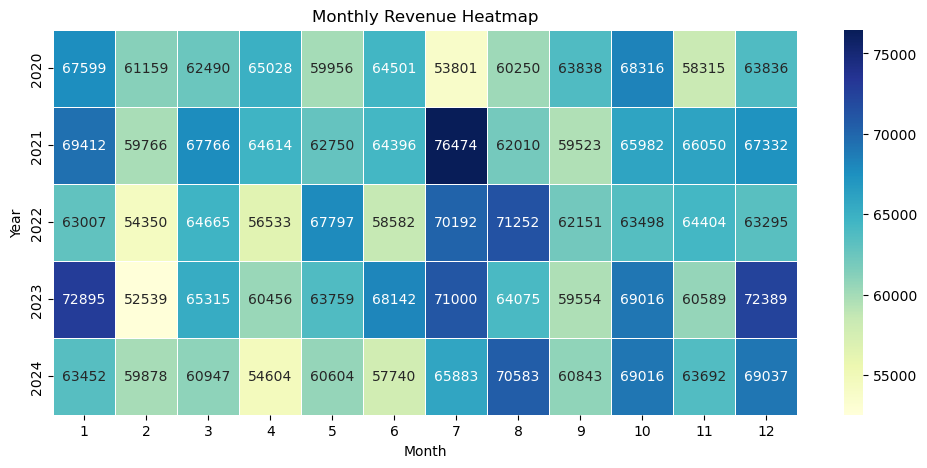

In [149]:
pivot = year_revenue.pivot(
    index='year',
    columns='month',
    values='revenue'
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Monthly Revenue Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

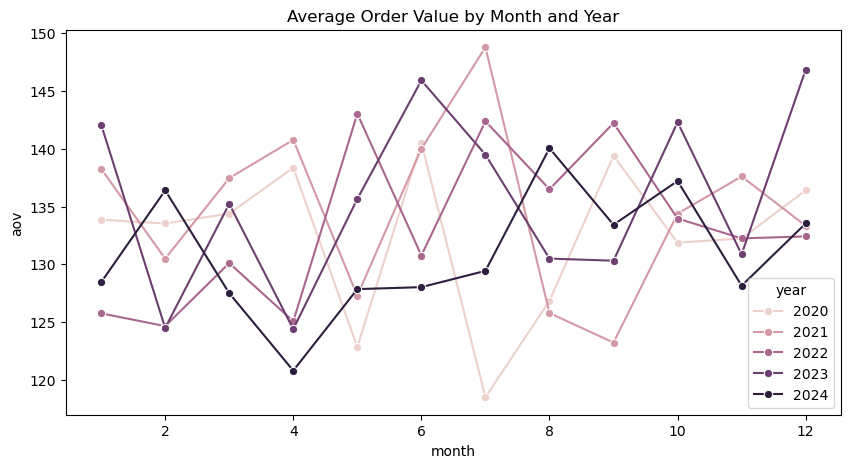

In [150]:
aov_change = """SELECT
    year,
    month,
    SUM(total_usd) / COUNT(order_id) AS aov
FROM orders
GROUP BY year, month
ORDER BY year, month;"""
aov_change = pd.read_sql(aov_change,engine)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=aov_change,
    x='month',
    y='aov',
    hue='year',
    marker='o'
)

plt.title('Average Order Value by Month and Year')
plt.show()

### Key Findings
- Annual revenue remained relatively stable throughout the analyzed period, ranging from approximately 749K to 780K.
- No strong long-term growth or decline in revenue was observed, indicating consistent business performance.
- Monthly revenue fluctuated between approximately 53K and 75K, with several temporary peaks and dips across different years.
- The revenue heatmap revealed no clear seasonal pattern, as high-performing months varied from year to year.
- Average Order Value (AOV) remained stable between approximately 120 and 145, suggesting consistent customer spending behavior.
- Since AOV showed limited variation while revenue fluctuated across months, revenue changes were likely driven by order volume rather than changes in customer spending per order.
- Overall, the sales analysis indicates a mature and stable business with predictable revenue and purchasing patterns.

### 3. Customer Analysis
   
 Key Questions
 
- How many customers have made at least one purchase?
- Which countries generate the most customers?
- Which countries generate the highest revenue?
- What percentage of customers are repeat buyers?
- Who are the most valuable customers?


In [151]:
purchasing_customers = """
SELECT COUNT(DISTINCT customer_id) AS purchasing_customers
FROM orders; """
purchasing_customers = pd.read_sql(purchasing_customers, engine)
purchasing_customers


,purchasing_customers
0,15260


In [152]:
cust_country = """
SELECT country,COUNT(DISTINCT customer_id)
FROM customers
GROUP BY 1
ORDER BY 2 DESC
LIMIT 5; """
cust_country = pd.read_sql(cust_country, engine)
cust_country


,country,COUNT(DISTINCT customer_id)
0,US,3648
1,IN,1589
2,GB,1585
3,BR,1421
4,DE,1397


In [153]:
country_rev = """
SELECT
    country,
    ROUND(SUM(total_usd), 2) AS total_revenue
FROM orders
GROUP BY country
ORDER BY total_revenue DESC
LIMIT 5; """
country_rev = pd.read_sql(country_rev, engine)
country_rev

,country,total_revenue
0,US,703005.75
1,GB,299718.72
2,IN,298820.91
3,BR,272004.99
4,DE,253270.85


In [154]:
repeat_buyers = """
WITH repeat_customers AS (
    SELECT customer_id
    FROM orders
    GROUP BY customer_id
    HAVING COUNT(order_id) > 1
)
SELECT
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(DISTINCT customer_id) FROM customers),
        2
    ) AS repeat_buyer_percentage
FROM repeat_customers; """
repeat_buyers = pd.read_sql(repeat_buyers, engine)
repeat_buyers

,repeat_buyer_percentage
0,42.38


In [155]:
most_valuable_cust = """SELECT
c.name,
c.customer_id,
c.country,
COUNT(o.order_id) AS total_orders,
ROUND(SUM(o.total_usd), 2) AS total_spent
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
GROUP BY
c.customer_id,name,
c.country
ORDER BY total_spent DESC
LIMIT 10; """
most_valuable_cust = pd.read_sql(most_valuable_cust, engine)
most_valuable_cust

,name,customer_id,country,total_orders,total_spent
0,Dr. Tiffany York PhD,17592,ES,2,3026.42
1,James Collins,372,US,3,2978.28
2,Micheal Howell,14135,PL,3,2588.95
3,Justin Little,13621,FR,2,2487.41
4,Megan May,3251,BR,3,2444.04
5,David Yang,6322,US,4,2230.66
6,Jacqueline Brown,8123,FR,4,2153.24
7,Angela Bridges,3640,SG,2,2122.89
8,Michael Nichols,503,MX,5,2100.96
9,Lawrence Johnson MD,10266,ES,2,1994.32


In [156]:
conv_to_purchase = """SELECT
ROUND(
    COUNT(DISTINCT customer_id) * 100.0 /
    (SELECT COUNT(*) FROM customers),
2) AS conversion_to_purchase
FROM orders; """
conv_to_purchase = pd.read_sql(conv_to_purchase, engine)
conv_to_purchase

,conversion_to_purchase
0,76.3


### Key Findings
- A total of 15,260 unique customers made at least one purchase during the analyzed period.
- The customer base is geographically diverse, with the United States representing the largest market with 3,648 customers, followed by India, the United Kingdom, Brazil, and Germany.
- The United States generated the highest revenue ($703K), contributing significantly more revenue than any other country.
- Although India had slightly more customers than the United Kingdom, the UK generated marginally higher revenue, indicating a higher average customer value.
- Approximately 42.4% of customers made more than one purchase, suggesting a moderate level of customer retention and repeat purchasing behavior.
- The top-spending customers generated between 2.1K and 3.0K in total revenue, despite placing only 2–5 orders, indicating a relatively high average order value among the most valuable customers.
- Revenue is concentrated among a relatively small group of high-value customers, highlighting opportunities for loyalty and retention initiatives.
- 76.3 % from All registered customers did a purchase.

### 4. Product Analysis
   
      Key Questions
   
- Which product categories generate the highest revenue?
- Which products are the best-selling?
- Which products generate the highest profit?
- Are there products with high sales but low profitability?


In [157]:
product_rev = """
SELECT
    p.category,
    ROUND(SUM(oi.quantity * oi.unit_price_usd), 2) AS revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC; """
product_rev = pd.read_sql(product_rev, engine)
product_rev

,category,revenue
0,Home & Kitchen,840379.82
1,Sports,831697.80
2,Fashion,824307.04
3,Electronics,692383.39
4,Beauty,691692.89
5,Toys,568734.90
6,Books,383155.39


In [158]:
best_selling = """
SELECT p.category, SUM(oi.quantity) AS sold
FROM products p
JOIN order_items oi
ON p.product_id = oi.product_id
GROUP BY 1
ORDER BY 2 DESC; """
best_selling = pd.read_sql(best_selling, engine)
best_selling

,category,sold
0,Books,16515.0
1,Toys,14861.0
2,Beauty,13313.0
3,Fashion,10045.0
4,Home & Kitchen,9453.0
5,Sports,8352.0
6,Electronics,4492.0


In [159]:
highest_margin = """SELECT
    p.name,
    ROUND(
        SUM((oi.unit_price_usd - p.cost_usd) * oi.quantity),
        2
    ) AS profit
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.name
ORDER BY profit DESC
LIMIT 10; """
highest_margin = pd.read_sql(highest_margin, engine)
highest_margin

,name,profit
0,Mouse RosyBrown 419,4394.50
1,Mouse Yellow 529,3855.38
2,Headphones Aquamarine 465,3780.96
3,Mouse MediumTurquoise 578,3758.12
4,Smartwatch DarkBlue 961,3738.24
5,Yoga Mat Navy 102,3651.20
6,Lamp Tomato 228,3631.18
7,Dumbbell MediumOrchid 520,3619.20
8,Cookware Ivory 298,3529.24
9,Webcam SlateGray 700,3455.48


In [160]:
high_sales_low_margin = """
SELECT
    p.name,
    SUM(oi.quantity * oi.unit_price_usd) AS revenue,
    SUM((oi.unit_price_usd - p.cost_usd) * oi.quantity) AS profit,
    ROUND(
        SUM((oi.unit_price_usd - p.cost_usd) * oi.quantity) * 100.0 /
        SUM(oi.quantity * oi.unit_price_usd),
        2
    ) AS profit_margin_pct
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.name
ORDER BY revenue DESC
LIMIT 30; """
high_sales_low_margin = pd.read_sql(high_sales_low_margin, engine)
high_sales_low_margin

,name,revenue,profit,profit_margin_pct
0,Mouse RosyBrown 419,9860.40,4394.50,44.57
1,Headphones Aquamarine 465,9286.88,3780.96,40.71
2,Webcam LightBlue 848,9212.80,3244.16,35.21
3,Mouse Chartreuse 292,8962.74,2945.16,32.86
4,Hoodie BlanchedAlmond 225,8874.24,2239.36,25.23
5,Tennis Racket PaleGreen 443,8778.44,3433.56,39.11
6,Cycling Helmet DarkKhaki 165,8709.28,2145.42,24.63
7,Smartwatch Moccasin 101,8616.56,2136.51,24.80
8,Water Bottle Gold 746,8284.95,3264.75,39.41
9,Mouse MediumTurquoise 578,8190.69,3758.12,45.88


### Key Findings
- Home & Kitchen generated the highest revenue (840K), closely followed by Sports (832K) and Fashion (824K).
- Books generated the lowest revenue ($383K), despite being the best-selling category by units sold.
- The highest-selling categories by quantity were Books (16.5K units), Toys (14.9K units), and Beauty (13.3K units).
- Categories with the highest sales volume did not necessarily generate the highest revenue, indicating substantial differences in average selling prices across categories.
- Electronics ranked among the top revenue-generating categories despite having the lowest number of units sold (4.5K units), suggesting a significantly higher average selling price.
- Several products generated more than (8K–10K) in revenue while maintaining profit margins below 30%, indicating potential opportunities for pricing optimization or supplier cost negotiations.
- The most profitable products generated approximately 3.5K–4.4K in total profit, demonstrating that profitability is concentrated among a relatively small group of products.
- Profit margins among top-selling products varied considerably, ranging from approximately 22% to 50%, highlighting differences in product profitability within the catalog.
- Products such as mice, headphones, smartwatches, and webcams appeared among both the top revenue and top profit rankings, making them strong candidates for promotional campaigns and inventory prioritization.

### 5. Marketing Analysis

Key Questions

- Which traffic sources generate the most revenue?
- Which traffic sources attract the most customers?
- Which devices generate the most revenue?
- Which devices have the highest average order value?
- Which countries generate the most revenue?
- Which marketing channels perform best?

In [161]:
revenue_by_source = """
SELECT
    source,
    ROUND(SUM(total_usd),2) AS revenue
FROM orders
GROUP BY source
ORDER BY revenue DESC; """
revenue_by_source = pd.read_sql(revenue_by_source, engine)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'organic'),
  Text(1, 0, 'direct'),
  Text(2, 0, 'paid'),
  Text(3, 0, 'social'),
  Text(4, 0, 'email'),
  Text(5, 0, 'referral')])

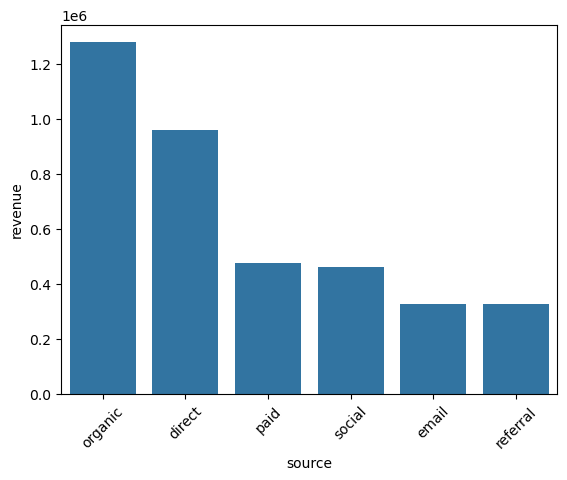

In [162]:
sns.barplot(
    data=revenue_by_source,
    x='source',
    y='revenue'
)
plt.xticks(rotation=45)

In [163]:
customers_by_source = """
SELECT
    source,
    COUNT(DISTINCT customer_id) AS customers
FROM orders
GROUP BY source
ORDER BY customers DESC; """
customers_by_source = pd.read_sql(customers_by_source, engine)
customers_by_source

,source,customers
0,organic,7696
1,direct,6012
2,paid,3234
3,social,3170
4,email,2469
5,referral,2209


In [164]:
revenue_per_customer_by_source = """
SELECT
    source,
    ROUND(
        SUM(total_usd) /
        COUNT(DISTINCT customer_id),
        2
    ) AS revenue_per_customer
FROM orders
GROUP BY source
ORDER BY revenue_per_customer DESC; """
revenue_per_customer_by_source = pd.read_sql(revenue_per_customer_by_source,engine)
revenue_per_customer_by_source

,source,revenue_per_customer
0,organic,165.99
1,direct,159.48
2,referral,147.72
3,paid,147.65
4,social,145.79
5,email,133.11


In [165]:
aov_by_device = """SELECT
    s.device,
    ROUND(AVG(o.total_usd),2) AS aov
FROM orders o
JOIN sessions s
    ON o.customer_id = s.customer_id
GROUP BY s.device
ORDER BY aov DESC; """
aov_by_device = pd.read_sql(aov_by_device, engine)
aov_by_device

,device,aov
0,desktop,133.71
1,mobile,133.53
2,tablet,132.04


### Key Findings

- Organic traffic is the most valuable acquisition channel

Organic generated the highest revenue (1.28M) and attracted the largest customer base (7.7K customers).
It also delivered the highest revenue per customer ($165.99), indicating strong customer quality and purchase intent.

- Direct traffic is a strong secondary revenue driver

Direct contributed approximately 0.94M in revenue from 6K customers.
Revenue per customer ($159.48) is only slightly below Organic, suggesting high brand awareness and customer loyalty.

- Paid traffic drives customers but not the highest value

Paid campaigns generated over 0.4M in revenue and acquired 3.2K customers.
Revenue per customer (147.65) is lower than Organic and Direct, indicating opportunities to improve campaign targeting and ROI.

- Referral channel delivers high-quality customers

Despite having the smallest customer base (2.2K customers), Referral users generated 147.72 revenue per customer, outperforming Social and Email channels.
This suggests referral traffic attracts highly engaged users.

- Email marketing shows the lowest customer value

Email customers generated only 133.11 revenue per customer, the lowest among all acquisition channels.
Additional segmentation and personalization may improve campaign effectiveness.

- Customer value is relatively consistent across devices

The difference between devices is minimal, indicating that purchasing behavior remains stable regardless of device type.

### 6. Marketing Analysis
- What is the average customer rating?
- How are ratings distributed?
- Which products receive the highest and lowest ratings?
- Which categories have the best and worst customer satisfaction?
- Does satisfaction differ by acquisition source?
- Do repeat customers leave higher ratings than new customers?
- Is there a relationship between order value and customer rating?

In [167]:
avg_rating = """
SELECT
    ROUND(AVG(rating),2) AS avg_rating
FROM reviews; """
avg_rating = pd.read_sql(avg_rating, engine)
avg_rating

,avg_rating
0,3.93


In [168]:
rating_distribution = """
SELECT
    rating,
    COUNT(*) AS reviews
FROM reviews
GROUP BY rating
ORDER BY rating; """
rating_distribution = pd.read_sql(rating_distribution, engine)
rating_distribution

,rating,reviews
0,1,423
1,2,757
2,3,1980
3,4,3565
4,5,4055


In [169]:
top_rated = """
SELECT
    p.category,
    ROUND(AVG(r.rating),2) AS avg_rating,
    COUNT(*) AS reviews
FROM reviews r
JOIN products p
    ON r.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_rating DESC; """
top_rated = pd.read_sql(top_rated, engine)
top_rated

,category,avg_rating,reviews
0,Beauty,3.97,1949
1,Sports,3.96,1113
2,Home & Kitchen,3.95,1344
3,Toys,3.93,1957
4,Fashion,3.93,1385
5,Books,3.92,2341
6,Electronics,3.87,691


In [170]:
rating_by_source = """
SELECT
    o.source,
    ROUND(AVG(r.rating),2) AS avg_rating
FROM reviews r
JOIN orders o
    ON r.order_id = o.order_id
GROUP BY o.source
ORDER BY avg_rating DESC; """
rating_by_source = pd.read_sql(rating_by_source, engine)
rating_by_source

,source,avg_rating
0,direct,3.96
1,referral,3.94
2,social,3.94
3,paid,3.93
4,organic,3.92
5,email,3.91


### Key findings
- The average customer rating is 3.93/5, indicating generally positive customer satisfaction, but there is still room for improvement.
- 5-star reviews are the most common (4,055 reviews).
- 4-star reviews are the second largest group (3,565 reviews).
- Low ratings are relatively rare:
1-star: 423 reviews
2-star: 757 reviews
- More than 75% of reviews are rated 4 or 5 stars, suggesting customers are largely satisfied with their purchases.
- Beauty products receive the highest customer satisfaction scores.
- Electronics has the lowest rating among all categories, which may indicate issues related to product quality, delivery expectations, or customer support.
- Category ratings are relatively close, suggesting a consistent customer experience across product lines.
- Customers acquired through Direct traffic provide the highest ratings.
- Email campaigns generate the lowest-rated customers, although the difference is small.
- Acquisition source has only a minor impact on satisfaction, indicating relatively consistent customer experience across marketing channels.

### Business Recommendations
1. Investigate why Electronics products receive lower ratings compared to other categories.
2. Analyze common themes in 1-star and 2-star reviews to identify recurring customer pain points.
3. Replicate successful practices from the Beauty category across other product categories.
4. Review customer journeys from Email campaigns to understand why these users report slightly lower satisfaction.
5. Maintain focus on customer experience, as strong review performance (average rating close to 4.0) is a positive indicator for retention and repeat purchases.

### 7. Retention Analysis


In [173]:
monthly_retention_rate = """
WITH first_purchase AS (
SELECT
customer_id,
MIN(order_time) AS first_order
FROM orders
GROUP BY customer_id
)
SELECT
YEAR(first_order) AS cohort_year,
COUNT(*) AS customers
FROM first_purchase
GROUP BY YEAR(first_order); """
monthly_retention_rate = pd.read_sql(monthly_retention_rate, engine)
monthly_retention_rate

,cohort_year,customers
0,2020,4907
1,2021,3828
2,2024,1531
3,2022,2812
4,2023,2182


In [174]:
repeat_customers = """
SELECT
COUNT(DISTINCT customer_id) AS repeat_customers
FROM (
    SELECT customer_id
    FROM orders
    GROUP BY customer_id
    HAVING COUNT(order_id) > 1
) t; """
repeat_customers = pd.read_sql(repeat_customers, engine)
repeat_customers

,repeat_customers
0,8475


In [175]:
retention = """
SELECT
ROUND(
COUNT(DISTINCT CASE WHEN order_count > 1 THEN customer_id END)
*100.0/
COUNT(DISTINCT customer_id),
2
) AS retention_rate
FROM (
    SELECT
    customer_id,
    COUNT(order_id) AS order_count
    FROM orders
    GROUP BY customer_id
) t; """
retention = pd.read_sql(retention, engine)
retention

,retention_rate
0,55.54


### 8. Cohort Analysis

In [180]:
cohort_table = """
WITH cohorts AS (
SELECT
customer_id,
DATE_FORMAT(MIN(order_time),'%%Y-%%m') AS cohort_month
FROM orders
GROUP BY customer_id
)
SELECT *
FROM cohorts; """
cohort_table = pd.read_sql(cohort_table, engine)
cohort_table

,customer_id,cohort_month
0,1022,2020-07
1,6145,2021-03
2,3152,2024-07
3,12378,2020-08
4,18712,2021-01
...,...,...
15255,11322,2022-11
15256,19426,2020-03
15257,2034,2024-09
15258,19817,2022-11


In [179]:
cohort_retention = """WITH cohorts AS (
SELECT
customer_id,
DATE_FORMAT(MIN(order_time),'%%Y-%%m') AS cohort_month
FROM orders
GROUP BY customer_id
),
activity AS (
SELECT
o.customer_id,
c.cohort_month,
TIMESTAMPDIFF(
MONTH,
STR_TO_DATE(CONCAT(c.cohort_month,'-01'),'%%Y-%%m-%%d'),
o.order_time
) AS month_number
FROM orders o
JOIN cohorts c
ON o.customer_id=c.customer_id
)
SELECT
cohort_month,
month_number,
COUNT(DISTINCT customer_id) AS customers
FROM activity
GROUP BY cohort_month,month_number; """
cohort_retention = pd.read_sql(cohort_retention, engine)
cohort_retention

,cohort_month,month_number,customers
0,2020-01,0,499
1,2020-01,1,11
2,2020-01,2,11
3,2020-01,3,17
4,2020-01,4,8
...,...,...,...
1820,2024-10,1,7
1821,2024-10,2,4
1822,2024-11,0,121
1823,2024-11,1,3


In [181]:
cohort_pivot = cohort_retention.pivot(
    index='cohort_month',
    columns='month_number',
    values='customers'
)

cohort_pivot.head()

month_number,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
cohort_month,,,,,,,,,,,,,,,,,,,,,
2020-01,499.0,11.0,11.0,17.0,8.0,12.0,16.0,17.0,12.0,8.0,...,19.0,9.0,13.0,12.0,12.0,23.0,10.0,11.0,8.0,17.0
2020-02,441.0,5.0,18.0,11.0,9.0,12.0,7.0,9.0,12.0,18.0,...,14.0,14.0,10.0,12.0,10.0,12.0,17.0,6.0,12.0,NaN
2020-03,439.0,10.0,8.0,8.0,9.0,6.0,14.0,15.0,9.0,8.0,...,5.0,10.0,15.0,10.0,9.0,10.0,11.0,12.0,NaN,NaN
2020-04,416.0,15.0,13.0,10.0,10.0,11.0,14.0,10.0,6.0,19.0,...,8.0,9.0,11.0,7.0,10.0,13.0,11.0,NaN,NaN,NaN
2020-05,441.0,14.0,11.0,9.0,6.0,11.0,9.0,9.0,14.0,10.0,...,10.0,15.0,16.0,15.0,13.0,9.0,NaN,NaN,NaN,NaN


In [182]:
cohort_size = cohort_pivot[0]

retention_matrix = cohort_pivot.divide(
    cohort_size,
    axis=0
) * 100

retention_matrix = retention_matrix.round(1)

retention_matrix.head()

month_number,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
cohort_month,,,,,,,,,,,,,,,,,,,,,
2020-01,100.0,2.2,2.2,3.4,1.6,2.4,3.2,3.4,2.4,1.6,...,3.8,1.8,2.6,2.4,2.4,4.6,2.0,2.2,1.6,3.4
2020-02,100.0,1.1,4.1,2.5,2.0,2.7,1.6,2.0,2.7,4.1,...,3.2,3.2,2.3,2.7,2.3,2.7,3.9,1.4,2.7,NaN
2020-03,100.0,2.3,1.8,1.8,2.1,1.4,3.2,3.4,2.1,1.8,...,1.1,2.3,3.4,2.3,2.1,2.3,2.5,2.7,NaN,NaN
2020-04,100.0,3.6,3.1,2.4,2.4,2.6,3.4,2.4,1.4,4.6,...,1.9,2.2,2.6,1.7,2.4,3.1,2.6,NaN,NaN,NaN
2020-05,100.0,3.2,2.5,2.0,1.4,2.5,2.0,2.0,3.2,2.3,...,2.3,3.4,3.6,3.4,2.9,2.0,NaN,NaN,NaN,NaN


In [187]:
retention_last_year = retention_matrix.tail(12)

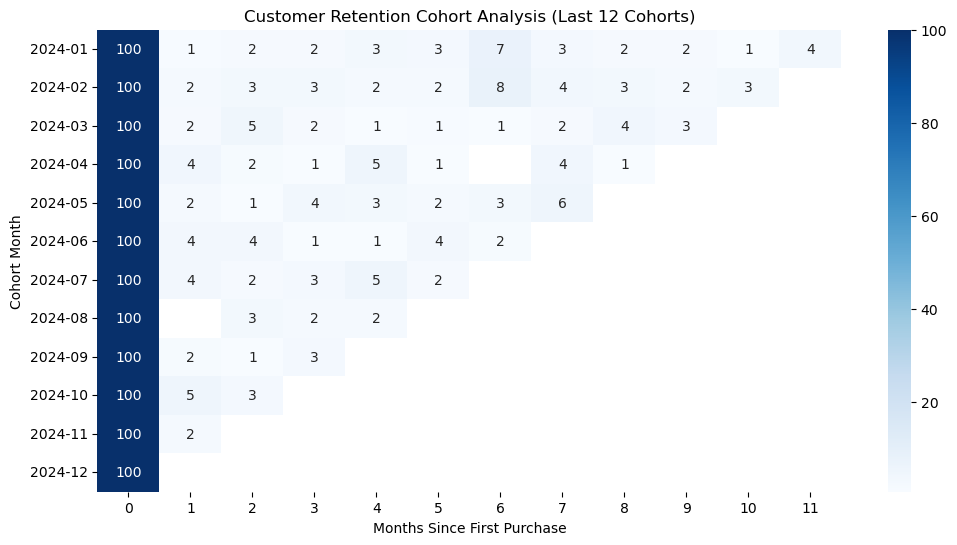

In [188]:
plt.figure(figsize=(12,6))

sns.heatmap(
    retention_last_year.iloc[:, :12],
    cmap='Blues',
    annot=True,
    fmt='.0f'
)

plt.title('Customer Retention Cohort Analysis (Last 12 Cohorts)')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')

plt.show()

### Key Finding
- Repeat customer rate is high: 55.54%.
- Monthly retention is low: mostly 1–8% after M0.
- This suggests that many customers repeat purchases, but not on a regular monthly basis.
- Customers return irregularly, not consistently every month.
- The company should focus on making repeat purchases more predictable through loyalty programs, reminders, and personalized offers.

### 8. RFM Analysis for  2024 year

In [198]:
rfm = """
WITH last_year_orders AS (
    SELECT *
    FROM orders
    WHERE order_time >= DATE_SUB(
        (SELECT MAX(order_time) FROM orders),
        INTERVAL 1 YEAR
    )
),

rfm_base AS (
    SELECT
        customer_id,

        DATEDIFF(
            (SELECT MAX(order_time) FROM orders),
            MAX(order_time)
        ) AS recency,

        COUNT(order_id) AS frequency,

        ROUND(SUM(total_usd), 2) AS monetary

    FROM last_year_orders
    GROUP BY customer_id
),

rfm_scores AS (
    SELECT
        customer_id,
        recency,
        frequency,
        monetary,

        6 - NTILE(5) OVER (ORDER BY recency) AS r_score,
        NTILE(5) OVER (ORDER BY frequency) AS f_score,
        NTILE(5) OVER (ORDER BY monetary) AS m_score

    FROM rfm_base
)

SELECT
    CASE
    WHEN r_score >= 4
         AND f_score >= 4
         AND m_score >= 4
    THEN 'Best Customers'

    WHEN r_score >= 3
         AND f_score >= 3
    THEN 'Loyal Customers'

    WHEN r_score <= 2
         AND f_score >= 3
    THEN 'At Risk'

    WHEN r_score <= 2
         AND f_score <= 2
    THEN 'Lost Customers'

    ELSE 'Others'
END AS segment,
customer_id,
    recency,
    frequency,
    monetary,
    r_score,
    f_score,
    m_score,
    CONCAT(r_score, f_score, m_score) AS rfm_score

FROM rfm_scores
ORDER BY monetary DESC; """
rfm = pd.read_sql(rfm, engine)
rfm

,segment,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,Others,10266,8,1,1700.37,5,1,5,515
1,Best Customers,4584,7,2,1691.16,5,5,5,555
2,Others,9842,84,1,1538.08,4,2,5,425
3,Others,1625,106,1,1501.17,4,2,5,425
4,At Risk,18881,303,1,1477.98,1,4,5,145
...,...,...,...,...,...,...,...,...,...
5009,At Risk,3957,238,1,4.32,2,4,1,241
5010,Others,5962,100,1,4.06,4,2,1,421
5011,Loyal Customers,1491,140,1,3.97,3,3,1,331
5012,Others,11660,52,1,3.50,5,2,1,521


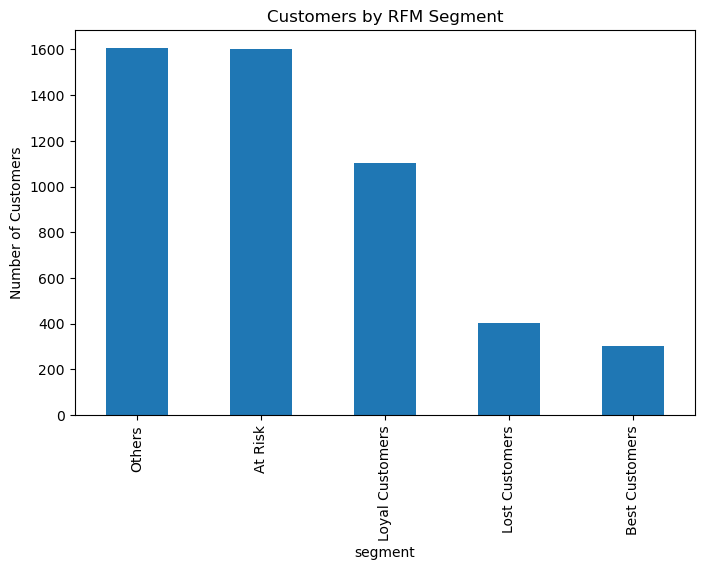

In [199]:
segment_counts = rfm['segment'].value_counts()

segment_counts.plot(
    kind='bar',
    figsize=(8,5),
    title='Customers by RFM Segment'
)
plt.ylabel('Number of Customers')
plt.show()

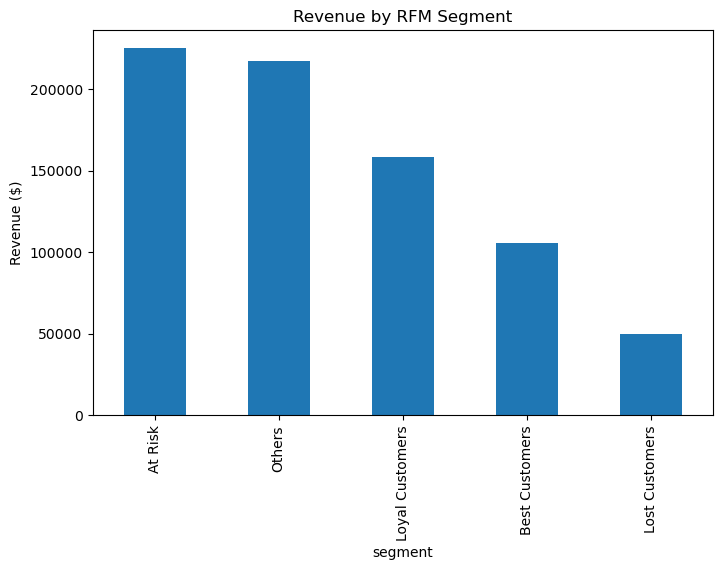

In [200]:
revenue_by_segment = (
    rfm.groupby('segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_segment.plot(
    kind='bar',
    figsize=(8,5),
    title='Revenue by RFM Segment'
)
plt.ylabel('Revenue ($)')
plt.show()

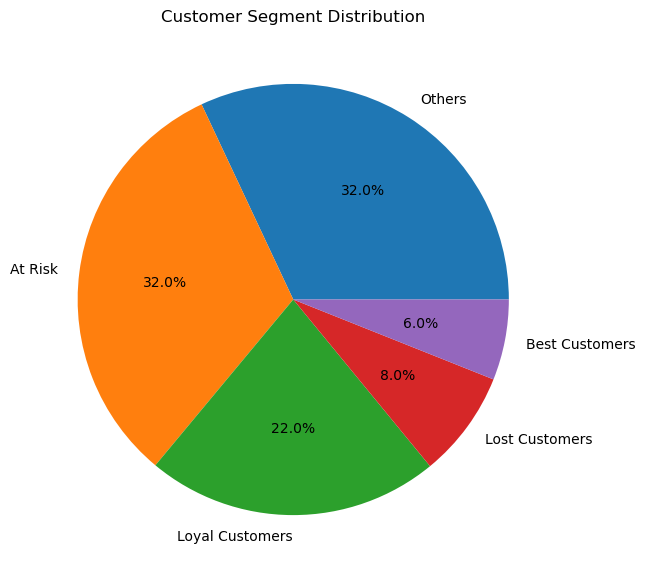

In [201]:
segment_share = (
    rfm['segment']
    .value_counts(normalize=True)*100
)

plt.figure(figsize=(7,7))
plt.pie(
    segment_share,
    labels=segment_share.index,
    autopct='%1.1f%%'
)
plt.title('Customer Segment Distribution')
plt.show()

## Key findings
### Revenue Contribution
- At Risk Customers generate the highest revenue, despite not being among the most active recent customers.
- Best Customers contribute significant revenue despite representing only 6% of customers, highlighting their high value to the business.
- Loyal Customers provide a stable revenue stream through repeat purchases and continued engagement.
- Revenue is concentrated within a relatively small number of valuable customer segments.
### Customer Behavior Insights
- A substantial proportion of customers are at risk of churning, creating a significant retention opportunity.
- The small size of the Best Customers segment suggests potential to grow this group through targeted loyalty initiatives.
- Many customers fall into the Others category, indicating a broad middle segment with potential for further segmentation and personalization.
- The presence of both Loyal and Best Customers demonstrates that the business is capable of building long-term customer relationships.